# 05 - Generacion condicional ASL

Este notebook entrena la parte inversa del proyecto: en lugar de predecir una clase desde una imagen (`Imagen -> Clase`), aprende a sintetizar una imagen condicionada por una etiqueta (`Clase -> Imagen`).

La implementacion usa una cGAN ligera, adecuada para imagenes ASL de `64x64` o `128x128`. El generador recibe ruido latente y un embedding de clase; el discriminador recibe la imagen junto con la condicion de clase. Al final se prueba el motor de secuenciacion que convierte una frase en un GIF de signos.

## 1. Preparacion del entorno

Ejecuta esta celda desde Jupyter abierto en la raiz del repositorio o desde la carpeta `notebooks/`. La celda localiza `PROJECT_ROOT`, carga utilidades del paquete `src/` y fija las semillas para reproducibilidad.

In [1]:
from __future__ import annotations

import copy
import sys
from pathlib import Path
from pprint import pprint

from IPython.display import Image as IPyImage, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_yaml_config
from src.utils.reproducibility import set_global_seed

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier


## 2. Carga y lectura de la configuracion

`configs/generation.yaml` concentra los hiperparametros del pipeline generativo: dimensiones latentes, embeddings de clase, resolucion de imagen, learning rates, tracking en W&B y rutas de salida. Cambia ese YAML si quieres que los cambios queden versionados; usa las celdas de override solo para pruebas rapidas.

In [2]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "generation.yaml"
config = load_yaml_config(CONFIG_PATH)
set_global_seed(int(config.get("seed", 42)))

pprint(config)

{'data': {'batch_size': 64,
          'image_size': 64,
          'num_workers': 0,
          'root_dir': 'data/asl_alphabet_v1/processed',
          'train_subdir': 'train',
          'val_subdir': 'val'},
 'device': 'auto',
 'experiment_name': 'conditional_gan',
 'metrics': {'batch_size': 32,
             'compute_fid': True,
             'compute_inception_score': True,
             'enabled': False,
             'interval': 5,
             'num_samples': 512},
 'model': {'discriminator_channels': [64, 128, 256, 512],
           'embedding_dim': 64,
           'generator_channels': [512, 256, 128, 64],
           'image_channels': 3,
           'label_smoothing': 0.9,
           'latent_dim': 128},
 'output': {'artifacts_dir': 'artifacts/generation',
            'checkpoint_name': 'conditional_gan.pt',
            'samples_dir': 'samples'},
 'seed': 42,
 'tracking': {'project': 'image-generation',
              'run_name': 'conditional-gan-asl',
              'tags': ['generation', 

Puntos importantes de la configuracion:

- `data.image_size`: resolucion entrenada por la cGAN. `64` es mucho mas rapido; `128` puede dar mas detalle, pero cuesta mas.
- `model.latent_dim`: tamaño del vector de ruido. Valores entre `64` y `256` suelen ser razonables.
- `model.embedding_dim`: tamaño del embedding aprendido para las 29 clases ASL.
- `training.sample_interval`: frecuencia con la que se guardan muestras con fixed noise.
- `metrics.enabled`: activa Inception Score y FID. Viene desactivado porque es mas lento y puede descargar pesos InceptionV3 si no estan cacheados.

## 3. Comprobacion del dataset

Antes de entrenar, comprobamos que el dataset procesado existe, que sigue la estructura `ImageFolder` generada por `scripts/prepare_dataset.py` y que contiene las clases esperadas: `A-Z`, `delete`, `nothing`, `space`.

In [3]:
from torchvision.utils import make_grid

from src.models.generative_models import DEFAULT_ASL_CLASSES, denormalize_generated_images
from src.training.gan_trainer import build_generation_dataloader

dataset, loader = build_generation_dataloader(config)
expected_classes = set(DEFAULT_ASL_CLASSES)
found_classes = set(dataset.classes)

print(f"Numero de imagenes de entrenamiento: {len(dataset):,}")
print(f"Numero de clases: {len(dataset.classes)}")
print(dataset.classes)

missing = sorted(expected_classes - found_classes)
extra = sorted(found_classes - expected_classes)
print(f"Clases esperadas no encontradas: {missing or 'ninguna'}")
print(f"Clases extra: {extra or 'ninguna'}")

assert not missing, "Faltan clases ASL esperadas en el dataset procesado."
assert len(dataset.classes) == 29, "El pipeline generativo espera 29 clases ASL."

Numero de imagenes de entrenamiento: 189,641
Numero de clases: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'delete', 'nothing', 'space']
Clases esperadas no encontradas: ninguna
Clases extra: ninguna


Visualizamos un lote real ya transformado a la resolucion de entrenamiento. Esto ayuda a detectar rutas mal configuradas, clases mezcladas o transformaciones inesperadas antes de gastar tiempo en el entrenamiento.

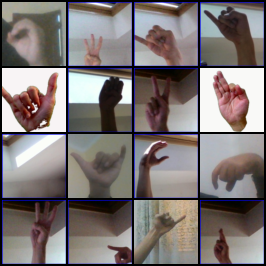

['O', 'W', 'J', 'J', 'Y', 'E', 'K', 'F', 'nothing', 'Y', 'C', 'Q', 'W', 'P', 'J', 'R']


In [4]:
real_images, real_labels = next(iter(loader))
preview_count = min(16, real_images.size(0))
grid = make_grid(denormalize_generated_images(real_images[:preview_count]), nrow=4, padding=2)
preview_path = PROJECT_ROOT / "artifacts" / "generation" / "real_batch_preview.png"
preview_path.parent.mkdir(parents=True, exist_ok=True)

from torchvision.utils import save_image

save_image(grid, preview_path)
display(IPyImage(filename=str(preview_path)))
print([dataset.classes[int(label)] for label in real_labels[:preview_count]])

## 4. Overrides opcionales para pruebas

Por defecto se entrena con los valores del YAML. Para validar que todo arranca sin esperar un entrenamiento completo, activa `QUICK_RUN = True`. Para usar W&B, deja `DISABLE_WANDB = False` y asegurate de tener `WANDB_API_KEY` en `.env`.

In [5]:
train_config = copy.deepcopy(config)

QUICK_RUN = True
DISABLE_WANDB = False
ENABLE_GENERATIVE_METRICS = True

if QUICK_RUN:
    train_config["training"]["epochs"] = 2
    train_config["training"]["checkpoint_interval"] = 1
    train_config["training"]["sample_interval"] = 1

if DISABLE_WANDB:
    train_config["tracking"]["use_wandb"] = False

train_config["metrics"]["enabled"] = ENABLE_GENERATIVE_METRICS

pprint(train_config)

{'data': {'batch_size': 64,
          'image_size': 64,
          'num_workers': 0,
          'root_dir': 'data/asl_alphabet_v1/processed',
          'train_subdir': 'train',
          'val_subdir': 'val'},
 'device': 'auto',
 'experiment_name': 'conditional_gan',
 'metrics': {'batch_size': 32,
             'compute_fid': True,
             'compute_inception_score': True,
             'enabled': True,
             'interval': 5,
             'num_samples': 512},
 'model': {'discriminator_channels': [64, 128, 256, 512],
           'embedding_dim': 64,
           'generator_channels': [512, 256, 128, 64],
           'image_channels': 3,
           'label_smoothing': 0.9,
           'latent_dim': 128},
 'output': {'artifacts_dir': 'artifacts/generation',
            'checkpoint_name': 'conditional_gan.pt',
            'samples_dir': 'samples'},
 'seed': 42,
 'tracking': {'project': 'image-generation',
              'run_name': 'conditional-gan-asl',
              'tags': ['generation', '

## 5. Entrenamiento de la cGAN

Esta celda ejecuta el trainer reusable de `src/training/gan_trainer.py`. Durante el entrenamiento se guardan:

- `artifacts/generation/conditional_gan.pt`: checkpoint final autocontenible.
- `artifacts/generation/conditional_gan_epoch_XXXX.pt`: checkpoints periodicos.
- `artifacts/generation/samples/epoch_XXXX.png`: cuadriculas generadas con fixed noise.
- En W&B: losses, muestras generadas y, si lo activas, Inception Score/FID.

In [6]:
from src.training.gan_trainer import train_conditional_gan

checkpoint_path = train_conditional_gan(train_config)
print(f"Checkpoint final: {checkpoint_path}")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: 202513902 (adne-image-classification) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\aleja/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:06<00:00, 17.5MB/s] 


discriminator_loss,█▁
epoch,▁█
fid,▁
generator_loss,▁█
inception_score,▁
discriminator_loss,0.27243
epoch,2
fid,266.85963
generator_loss,3.73812
inception_score,1.94555


Checkpoint final: C:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier\artifacts\generation\conditional_gan.pt


## 6. Inspeccion visual de muestras generadas

Las GANs se diagnostican mucho por inspeccion visual. Mira si las muestras mantienen forma de mano, variedad entre clases y estabilidad entre epochs. Si ves ruido puro durante muchas epochs, reduce learning rate, aumenta epochs o revisa que las imagenes reales carguen bien.

Mostrando: c:\Users\aleja\Documents\Comillas\2º Cuatri\Análisis de Datos no Estructurados\signlanguage-classifier\artifacts\generation\samples\epoch_0002.png


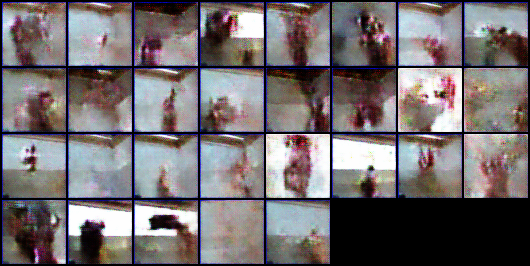

In [7]:
samples_dir = PROJECT_ROOT / train_config["output"]["artifacts_dir"] / train_config["output"]["samples_dir"]
sample_files = sorted(samples_dir.glob("*.png"))

if not sample_files:
    print(f"No hay muestras todavia en {samples_dir}. Ejecuta primero la celda de entrenamiento.")
else:
    latest_sample = sample_files[-1]
    print(f"Mostrando: {latest_sample}")
    display(IPyImage(filename=str(latest_sample)))

## 7. Prueba del motor frase -> GIF

`generate_phrase_sequence()` tokeniza la frase caracter a caracter, ignora simbolos no soportados y convierte espacios en la clase `space`. Si existe un checkpoint entrenado, genera cada frame con la cGAN; si no, usa imagenes del dataset como fallback para que Streamlit siga siendo usable.

Labels: ['H', 'A', 'L', 'A']
Skipped: []
Source: model


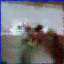

In [13]:
from src.inference.generator import generate_phrase_sequence, resolve_default_generator_checkpoint

resolved_checkpoint = checkpoint_path if "checkpoint_path" in globals() else resolve_default_generator_checkpoint()
sequence = generate_phrase_sequence(
    phrase="hala",
    frame_duration=1,
    checkpoint_path=resolved_checkpoint,
)

print("Labels:", sequence.labels)
print("Skipped:", sequence.skipped_characters)
print("Source:", sequence.source)
display(IPyImage(data=sequence.gif_bytes, format="gif"))

## 8. Conexion con Streamlit

La app busca automaticamente `artifacts/generation/conditional_gan.pt`. Una vez entrenado el modelo, lanza:

```bash
streamlit run app/streamlit_app.py
```

En el modo `Generacion`, escribe una frase, selecciona la duracion de frame entre `0.5s` y `2.0s`, visualiza el GIF y descargalo. Si quieres apuntar a otro checkpoint, define `GENERATOR_MODEL_PATH` en `.env`.